In [ ]:
# (MÓDULO 1) – Imports
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from dateutil.relativedelta import relativedelta

print(">> M1 OK: imports carregados")


>> M1 OK: imports carregados


In [ ]:
# (MÓDULO 2) – Leitura da base

df_path= "/content/final_dataset_aw.csv"
print(">> Lendo CSV...")
df = pd.read_csv(df_path)
print("shape:", df.shape)
print("colunas:", list(df.columns))
print("\nAmostra de 5 linhas:")
print(df.head())

>> Lendo CSV...
shape: (68520, 21)
colunas: ['order_date', 'product_id', 'product_name', 'product_line', 'product_class', 'product_style', 'territory_id', 'territory_name', 'country_region_code', 'year', 'month', 'quarter', 'day_of_week', 'is_weekend', 'week_of_year', 'week_start_date', 'month_end_date', 'total_items_sold', 'total_orders', 'total_gross_revenue', 'any_online_order']

Amostra de 5 linhas:
   order_date  product_id           product_name product_line product_class  \
0  2011-05-31         707  Sport-100 Helmet, Red           S            NaN   
1  2011-05-31         707  Sport-100 Helmet, Red           S            NaN   
2  2011-05-31         707  Sport-100 Helmet, Red           S            NaN   
3  2011-05-31         707  Sport-100 Helmet, Red           S            NaN   
4  2011-05-31         707  Sport-100 Helmet, Red           S            NaN   

  product_style  territory_id territory_name country_region_code  year  ...  \
0           NaN             1      Nort

In [ ]:
# (MÓDULO 3) – Padronização temporal + FEATURES (month/quarter)
print("\n>> Convertendo 'order_date' e criando 'year_month' (fim do mês)...")
df['order_date'] = pd.to_datetime(df['order_date'])
df['year_month'] = df['order_date'].dt.to_period('M').dt.to_timestamp('M')

# features de calendário
df['month']   = df['year_month'].dt.month
df['quarter'] = df['year_month'].dt.quarter

print("Período observado:", df['order_date'].min(), "→", df['order_date'].max())
print(df[['order_date','year_month','month','quarter']].head())
print(">> M3 OK")



>> Convertendo 'order_date' e criando 'year_month' (fim do mês)...
Período observado: 2011-05-31 00:00:00 → 2014-06-30 00:00:00
  order_date year_month  month  quarter
0 2011-05-31 2011-05-31      5        2
1 2011-05-31 2011-05-31      5        2
2 2011-05-31 2011-05-31      5        2
3 2011-05-31 2011-05-31      5        2
4 2011-05-31 2011-05-31      5        2
>> M3 OK


In [ ]:
# (MÓDULO 4) – Agregação produto x loja (territory) x mês
key_cols = [
    'product_id','product_name',
    'territory_id','territory_name',
    'country_region_code','year_month'
]
measure_col = 'total_items_sold'

print("\n>> Agregando por produto x loja x mês...")
agg = (df[key_cols + [measure_col,'month','quarter']]
       .groupby(key_cols + ['month','quarter'], as_index=False)
       .agg(total_qty=(measure_col,'sum')))

print("shape agregada:", agg.shape)
print(agg.head(10))
print(">> M4 OK")



>> Agregando por produto x loja x mês...
shape agregada: (26710, 9)
   product_id           product_name  territory_id territory_name  \
0         707  Sport-100 Helmet, Red             1      Northwest   
1         707  Sport-100 Helmet, Red             1      Northwest   
2         707  Sport-100 Helmet, Red             1      Northwest   
3         707  Sport-100 Helmet, Red             1      Northwest   
4         707  Sport-100 Helmet, Red             1      Northwest   
5         707  Sport-100 Helmet, Red             1      Northwest   
6         707  Sport-100 Helmet, Red             1      Northwest   
7         707  Sport-100 Helmet, Red             1      Northwest   
8         707  Sport-100 Helmet, Red             1      Northwest   
9         707  Sport-100 Helmet, Red             1      Northwest   

  country_region_code year_month  month  quarter  total_qty  
0                  US 2011-05-31      5        2          4  
1                  US 2011-07-31      7        

In [ ]:
# (MÓDULO 5) – Calendário contínuo + índice temporal t + flags de zeros
panel_keys = ['product_id','product_name','territory_id','territory_name','country_region_code']

def expand_months(g: pd.DataFrame) -> pd.DataFrame:
    idx = pd.date_range(g['year_month'].min(), g['year_month'].max(), freq='M')
    g2 = (g.set_index('year_month')
            .reindex(idx)
            .rename_axis('year_month')
            .reset_index())
    return g2

print("\n>> Expandindo calendário mensal por série...")
agg_full = (agg.sort_values('year_month')
              .groupby(panel_keys, group_keys=False)
              .apply(expand_months)
           )

# Preenchendo chaves/tempo
for c in panel_keys:
    agg_full[c] = agg_full.groupby(panel_keys)[c].ffill().bfill()
agg_full['month']   = agg_full['year_month'].dt.month
agg_full['quarter'] = agg_full['year_month'].dt.quarter

# Quantidade e flags
agg_full['total_qty'] = agg_full['total_qty'].fillna(0)
agg_full['t'] = agg_full.groupby(panel_keys).cumcount() + 1
agg_full['has_sales'] = (agg_full['total_qty'] > 0).astype(int)

# Densidade de zeros por série
zero_stats = (agg_full
              .groupby(panel_keys)['has_sales']
              .agg(nonzero_cnt='sum', total_cnt='count')
              .reset_index())
zero_stats['zero_ratio'] = 1 - (zero_stats['nonzero_cnt']/zero_stats['total_cnt'])

agg_full = agg_full.merge(zero_stats, on=panel_keys, how='left')

print("shape pós-expand:", agg_full.shape)
print("Checagem total_qty NaN:", agg_full['total_qty'].isna().sum()==0)
print("Distribuição zero_ratio (amostra):")
print(zero_stats['zero_ratio'].describe())
print(">> M5 OK")



>> Expandindo calendário mensal por série...


/tmp/ipython-input-1970151260.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  idx = pd.date_range(g['year_month'].min(), g['year_month'].max(), freq='M')
/tmp/ipython-input-1970151260.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  idx = pd.date_range(g['year_month'].min(), g['year_month'].max(), freq='M')
/tmp/ipython-input-1970151260.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  idx = pd.date_range(g['year_month'].min(), g['year_month'].max(), freq='M')
/tmp/ipython-input-1970151260.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  idx = pd.date_range(g['year_month'].min(), g['year_month'].max(), freq='M')
/tmp/ipython-input-1970151260.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  idx = pd.da

shape pós-expand: (34814, 14)
Checagem total_qty NaN: True
Distribuição zero_ratio (amostra):
count    2446.000000
mean        0.232867
std         0.215855
min         0.000000
25%         0.000000
50%         0.171429
75%         0.384615
max         0.846154
Name: zero_ratio, dtype: float64
>> M5 OK


/tmp/ipython-input-1970151260.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(expand_months)


In [ ]:
# (MÓDULO 6) – Backtest e seleção de estratégia por série (fix listas→np arrays)
# Estratégias avaliadas:
#   - baseline_ma2
#   - baseline_ewma_s2 / s3 / s4  (span=2,3,4)  -> EWMA_best
#   - ridge_t_nonzero             (treina só em pontos > 0; X=[t])
#   - ensemble(EWMA_best, ridge)  (média simples, quando ridge existe)
#
# Regras:
#   - Se zero_ratio >= 0.7 → priorizar baseline (EWMA_best); ridge pode ser ignorado
#   - Se nonzero_cnt < 3 para regressão → não treinar ridge
#   - Seleção por menor RMSE no holdout (último mês) entre estratégias válidas
#   - Métricas: MAE, RMSE, MAPE, SMAPE

from sklearn.metrics import mean_squared_error

def _to_np(a):
    return np.asarray(a, dtype=float)

def _rmse(y, yhat):
    y    = _to_np(y)
    yhat = _to_np(yhat)
    return np.sqrt(mean_squared_error(y, yhat))

def _mae(y, yhat):
    y    = _to_np(y)
    yhat = _to_np(yhat)
    return np.mean(np.abs(y - yhat))

def _mape(y, yhat):
    y    = _to_np(y)
    yhat = _to_np(yhat)
    denom = np.where(y == 0.0, 1.0, y)  # evita divisão por zero
    return (np.abs((y - yhat) / denom)).mean() * 100.0

def _smape(y, yhat):
    y    = _to_np(y)
    yhat = _to_np(yhat)
    denom = np.abs(y) + np.abs(yhat)
    denom = np.where(denom == 0.0, 1.0, denom)
    return (np.mean(2.0 * np.abs(y - yhat) / denom)) * 100.0

def _baseline_ma2(train):
    if len(train) >= 2:
        return float(train['total_qty'].rolling(2).mean().iloc[-1])
    return float(train['total_qty'].iloc[-1])

def _baseline_ewma(train, span):
    # usa apenas histórico observado
    if len(train) >= 1:
        return float(train['total_qty'].ewm(span=span).mean().iloc[-1])
    return float(train['total_qty'].iloc[-1])

def _ridge_t_nonzero(train, test):
    sub = train[train['has_sales'] == 1]
    if len(sub) < 3:
        return None  # insuficiente para treinar
    X_tr = sub[['t']].values
    y_tr = sub['total_qty'].values
    mdl = Ridge(alpha=1.0).fit(X_tr, y_tr)
    X_te = test[['t']].values
    pred = float(mdl.predict(X_te)[0])
    return max(0.0, pred)

def _ensemble_mean(a, b):
    return float((a + b) / 2.0)

def backtest_series_v3(g):
    """Holdout do último mês para seleção de estratégia por série."""
    if len(g) < 3:
        return None
    g = g.sort_values('year_month')
    train = g.iloc[:-1]
    test  = g.iloc[-1:]
    y_true = float(test['total_qty'].iloc[0])
    zr = float(train['zero_ratio'].iloc[-1])  # constante por série
    nz = int(train['has_sales'].sum())

    # Baselines
    pred_ma2 = _baseline_ma2(train)
    pred_e2  = _baseline_ewma(train, 2)
    pred_e3  = _baseline_ewma(train, 3)
    pred_e4  = _baseline_ewma(train, 4)

    ewma_dict = {
        'baseline_ewma_s2': pred_e2,
        'baseline_ewma_s3': pred_e3,
        'baseline_ewma_s4': pred_e4
    }
    # heurística simples: entre as EWMAs, escolhe a que mais se aproxima do holdout
    ewma_best_name = min(ewma_dict, key=lambda k: abs(ewma_dict[k] - y_true))
    ewma_best_pred = ewma_dict[ewma_best_name]

    # Ridge (só se há pontos > 0 suficientes e série não é extremamente esparsa)
    pred_ridge = None if (zr >= 0.7 or nz < 3) else _ridge_t_nonzero(train, test)

    # Ensemble quando ambos existem
    pred_ens = None
    if pred_ridge is not None:
        pred_ens = _ensemble_mean(ewma_best_pred, pred_ridge)

    # Candidatos válidos
    candidates = {
        'baseline_ma2': pred_ma2,
        ewma_best_name: ewma_best_pred,
    }
    if pred_ridge is not None:
        candidates['ridge_t_nonzero'] = pred_ridge
    if pred_ens is not None:
        candidates['ensemble_ewma_ridge'] = pred_ens

    # Seleção por menor RMSE no holdout
    best_model = None
    best_pred  = None
    best_rmse  = float('inf')
    for name, pred in candidates.items():
        rmse = _rmse([y_true], [pred])
        if rmse < best_rmse:
            best_rmse, best_model, best_pred = rmse, name, pred

    # Métricas do vencedor (no holdout)
    mae  = _mae([y_true], [best_pred])
    rmse = best_rmse
    mape = _mape([y_true], [best_pred])
    smape= _smape([y_true], [best_pred])

    return {
        'y_true': y_true,
        'best_model': best_model,
        'best_pred': max(0.0, float(best_pred)),
        'baseline_ma2': pred_ma2,
        'baseline_ewma_s2': pred_e2,
        'baseline_ewma_s3': pred_e3,
        'baseline_ewma_s4': pred_e4,
        'ridge_t_nonzero': (np.nan if pred_ridge is None else pred_ridge),
        'ensemble_ewma_ridge': (np.nan if pred_ens   is None else pred_ens),
        'zero_ratio': zr,
        'nonzero_cnt': nz,
        'MAE': mae, 'RMSE': rmse, 'MAPE_%': mape, 'SMAPE_%': smape
    }

print("\n>> Rodando backtest v3 (seleção por série)...")
bt_rows = []
for key, g in agg_full.groupby(panel_keys, sort=False):
    res = backtest_series_v3(g)
    if res is not None:
        bt_rows.append({**{k:v for k,v in zip(panel_keys, key)}, **res})

bt = pd.DataFrame(bt_rows)

print("Séries avaliadas:", bt.shape[0])
print("Amostra do backtest:")
print(bt.head())

# Visão geral das estratégias vencedoras
winner_stats = bt['best_model'].value_counts(dropna=False)
print("\nModelos vencedores por contagem:")
print(winner_stats)

# Métricas agregadas (média) do vencedor por série
metrics_overall = bt[['MAE','RMSE','MAPE_%','SMAPE_%']].mean().to_frame('mean').T
print("\nMétricas globais (média do vencedor por série):")
print(metrics_overall)

print(">> M6 OK")



>> Rodando backtest v3 (seleção por série)...
Séries avaliadas: 2319
Amostra do backtest:
   product_id           product_name  territory_id territory_name  \
0       707.0  Sport-100 Helmet, Red           1.0      Northwest   
1       707.0  Sport-100 Helmet, Red           2.0      Northeast   
2       707.0  Sport-100 Helmet, Red           3.0        Central   
3       707.0  Sport-100 Helmet, Red           4.0      Southwest   
4       707.0  Sport-100 Helmet, Red           5.0      Southeast   

  country_region_code  y_true       best_model  best_pred  baseline_ma2  \
0                  US    14.0     baseline_ma2  35.000000          35.0   
1                  US    10.0     baseline_ma2  11.500000          11.5   
2                  US    17.0  ridge_t_nonzero  17.032153          16.5   
3                  US    12.0     baseline_ma2  49.000000          49.0   
4                  US     1.0     baseline_ma2  10.500000          10.5   

   baseline_ewma_s2  baseline_ewma_s3  base

In [ ]:
# (MÓDULO 7) – Previsões 3M à frente usando a estratégia vencedora por série

def _predict_baseline_ma2_series(series: pd.Series) -> float:
    if len(series) >= 2:
        return float(series.rolling(2).mean().iloc[-1])
    return float(series.iloc[-1])

def _predict_baseline_ewma_series(series: pd.Series, span: int) -> float:
    return float(series.ewm(span=span).mean().iloc[-1])

def _ridge_predict_next(hist_df: pd.DataFrame, next_t_value: int) -> float | None:
    """
    Treina Ridge em pontos >0 (has_sales==1) do histórico OBSERVADO
    e prevê para o t solicitado (next_t_value).
    """
    sub = hist_df[hist_df['has_sales'] == 1]
    if len(sub) < 3:
        return None
    X_tr = sub[['t']].values
    y_tr = sub['total_qty'].values
    mdl  = Ridge(alpha=1.0).fit(X_tr, y_tr)
    yhat = float(mdl.predict(np.array([[next_t_value]]) )[0])
    return max(0.0, yhat)

def _forecast3_by_strategy(g: pd.DataFrame) -> pd.DataFrame | None:
    """Gera 3 passos à frente respeitando a estratégia vencedora da série (definida no MÓDULO 6)."""
    g = g.sort_values('year_month').copy()

    # Identifica a série no dataframe de backtest 'bt'
    key = tuple(g[panel_keys].iloc[0].values)
    row = bt[(bt['product_id']==key[0]) &
             (bt['product_name']==key[1]) &
             (bt['territory_id']==key[2]) &
             (bt['territory_name']==key[3]) &
             (bt['country_region_code']==key[4])]
    if row.empty:
        return None
    best_model = row['best_model'].iloc[0]

    # Setup histórico
    last_month = g['year_month'].iloc[-1]
    last_t     = int(g['t'].iloc[-1])

    # Histórico OBSERVADO para o Ridge (não adicionamos previsões aqui)
    g_observed = g[['t','total_qty','has_sales']].copy()

    # Histórico para as baselines (aqui sim adicionamos previsões recursivamente)
    curr_series     = g['total_qty'].copy().reset_index(drop=True)
    curr_has_sales  = g['has_sales'].copy().reset_index(drop=True)

    preds, months = [], []
    for step in range(1, 4):
        target_month = (last_month + relativedelta(months=step)).to_period('M').to_timestamp('M')
        months.append(target_month)
        next_t = last_t + step

        # Baselines (recursivas sobre a série corrente, que recebe previsões)
        p_ma2 = _predict_baseline_ma2_series(curr_series)
        p_e2  = _predict_baseline_ewma_series(curr_series, 2)
        p_e3  = _predict_baseline_ewma_series(curr_series, 3)
        p_e4  = _predict_baseline_ewma_series(curr_series, 4)

        ewma_map = {'baseline_ewma_s2': p_e2, 'baseline_ewma_s3': p_e3, 'baseline_ewma_s4': p_e4}

        # Se o vencedor foi uma EWMA específica, use-a; do contrário, escolha a mais próxima do último valor observado
        if best_model in ewma_map:
            p_ewma_best = ewma_map[best_model]
        else:
            last_val = curr_series.iloc[-1] if len(curr_series) else 0.0
            p_ewma_best = min(ewma_map.values(), key=lambda x: abs(x - last_val))

        # Ridge usando apenas histórico observado (>0) e prevendo para next_t
        pred_ridge_next = _ridge_predict_next(g_observed, next_t)

        # Combinação conforme estratégia vencedora
        if best_model == 'baseline_ma2':
            pred_final = p_ma2
        elif best_model in ['baseline_ewma_s2','baseline_ewma_s3','baseline_ewma_s4']:
            pred_final = p_ewma_best
        elif best_model == 'ridge_t_nonzero':
            pred_final = pred_ridge_next if pred_ridge_next is not None else p_ewma_best
        elif best_model == 'ensemble_ewma_ridge':
            if pred_ridge_next is not None:
                pred_final = (p_ewma_best + pred_ridge_next) / 2.0
            else:
                pred_final = p_ewma_best
        else:
            pred_final = p_ewma_best  # fallback seguro

        pred_final = max(0.0, float(pred_final))
        preds.append(pred_final)

        # Atualiza série para o próximo passo (para as baselines recursivas)
        curr_series = pd.concat([curr_series, pd.Series([pred_final])], ignore_index=True)
        curr_has_sales = pd.concat([curr_has_sales, pd.Series([1 if pred_final > 0 else 0])], ignore_index=True)

    out = pd.DataFrame({'year_month': months, 'forecast_qty': preds})
    return out

print("\n>> Gerando previsões 3M por série conforme estratégia vencedora...")
fc_rows = []
for key, g in agg_full.groupby(panel_keys, sort=False):
    if len(g) >= 2:
        meta = pd.DataFrame([list(key)]*3, columns=panel_keys).reset_index(drop=True)
        fc = _forecast3_by_strategy(g)
        if fc is not None:
            fc_rows.append(pd.concat([meta, fc], axis=1))

final_fc = pd.concat(fc_rows, ignore_index=True)
print("Amostra de previsões finais:")
print(final_fc.head(50))
print(">> M7 OK")



>> Gerando previsões 3M por série conforme estratégia vencedora...
Amostra de previsões finais:
    product_id             product_name  territory_id  territory_name  \
0        707.0    Sport-100 Helmet, Red           1.0       Northwest   
1        707.0    Sport-100 Helmet, Red           1.0       Northwest   
2        707.0    Sport-100 Helmet, Red           1.0       Northwest   
3        707.0    Sport-100 Helmet, Red           2.0       Northeast   
4        707.0    Sport-100 Helmet, Red           2.0       Northeast   
5        707.0    Sport-100 Helmet, Red           2.0       Northeast   
6        707.0    Sport-100 Helmet, Red           3.0         Central   
7        707.0    Sport-100 Helmet, Red           3.0         Central   
8        707.0    Sport-100 Helmet, Red           3.0         Central   
9        707.0    Sport-100 Helmet, Red           4.0       Southwest   
10       707.0    Sport-100 Helmet, Red           4.0       Southwest   
11       707.0    Sport-100

In [ ]:
 # (MÓDULO 8) – Crescimento US vs Rest of World (3M previstos vs últimos 3M históricos)
print("\n>> Calculando crescimento US vs RoW ...")
hist_start = agg_full['year_month'].max() - pd.offsets.MonthEnd(2)  # últimos 3 meses
hist_recent = (agg_full.query("year_month >= @hist_start")
               .groupby(['country_region_code','territory_name'])['total_qty']
               .sum()
               .reset_index())

future_3m = final_fc.groupby(['country_region_code','territory_name'])['forecast_qty'].sum().reset_index()

label_group = lambda cc: "US (provinces)" if cc == "US" else "Rest of World"
hist_recent['group'] = hist_recent['country_region_code'].map(label_group)
future_3m['group']   = future_3m['country_region_code'].map(label_group)

hist_group = hist_recent.groupby('group')['total_qty'].sum().reset_index(name='history_qty')
fut_group  = future_3m .groupby('group')['forecast_qty'].sum().reset_index()
growth = hist_group.merge(fut_group, on='group', how='outer').fillna(0.0)
growth['growth_qty'] = growth['forecast_qty'] - growth['history_qty']
growth['growth_%']   = np.where(growth['history_qty']==0, np.nan,
                                100.0 * growth['growth_qty'] / growth['history_qty'])

print("Tabela de crescimento:")
print(growth)
print(">> M8 OK")



>> Calculando crescimento US vs RoW ...
Tabela de crescimento:
            group  history_qty  forecast_qty    growth_qty    growth_%
0   Rest of World      13179.0  22594.960698   9415.960698   71.446701
1  US (provinces)      10148.0  28726.173852  18578.173852  183.072269
>> M8 OK


In [ ]:
# (MÓDULO 9) – Zíperes para luvas (2 por par) — versão persistente
import pandas as pd
import numpy as np

print("\n>> Estimando zíperes para luvas (2 por par) com base nos product_id informados...")

KNOWN_GLOVE_IDS = [858, 859, 860, 861, 862, 863]
print("IDs de luvas (esperados):", KNOWN_GLOVE_IDS)

def _to_int_or_nan(v):
    try:
        if isinstance(v, float) and v.is_integer():
            return int(v)
        return int(v)
    except Exception:
        return np.nan

# cópias normalizadas
df_gloves = df.copy()
df_gloves['product_id_norm'] = df_gloves['product_id'].apply(_to_int_or_nan)

fc_gloves = final_fc.copy()
fc_gloves['product_id_norm'] = fc_gloves['product_id'].apply(_to_int_or_nan)

# diagnósticos
hist_ids = sorted(pd.Series(df_gloves['product_id_norm'].dropna().unique()).astype(int).tolist())
fc_ids   = sorted(pd.Series(fc_gloves['product_id_norm'].dropna().unique()).astype(int).tolist())
print("product_id presentes no HISTÓRICO (normalizados):", hist_ids[:20], "... (total:", len(hist_ids), ")")
print("product_id presentes nas PREVISÕES (normalizados):", fc_ids[:20], "... (total:", len(fc_ids), ")")

present = sorted([pid for pid in KNOWN_GLOVE_IDS if pid in fc_ids])
missing = sorted([pid for pid in KNOWN_GLOVE_IDS if pid not in fc_ids])

print("Luvas encontradas nas PREVISÕES:", present)
print("Luvas NÃO encontradas nas PREVISÕES:", missing)

# cálculo
if present:
    gloves_fc = fc_gloves[fc_gloves['product_id_norm'].isin(present)].copy()

    glove_summary = (gloves_fc
        .groupby(['product_id','product_id_norm','product_name'], dropna=False)['forecast_qty']
        .sum().reset_index()
        .sort_values('forecast_qty', ascending=False))

    total_glove_pairs = float(gloves_fc['forecast_qty'].sum())
    zippers_needed = 2.0 * total_glove_pairs
    note = "Computed from forecasts by product_id (2 zippers per pair)"
else:
    glove_summary = pd.DataFrame(columns=['product_id','product_id_norm','product_name','forecast_qty'])
    total_glove_pairs = 0.0
    zippers_needed = 0.0
    note = "Nenhum dos product_id de luvas apareceu em final_fc (ver 'missing')."

# arredondar só para apresentação (mantendo precisão no CSV se quiser)
res_dict = {
    'total_glove_pairs_next_3m': total_glove_pairs,
    'zippers_needed_next_3m': zippers_needed,
    'note': note
}

print("\nResumo por (product_id_norm, product_name):")
print(glove_summary.head(20))

print("\nResultado final (luvas por IDs informados):")
print({k: round(v, 3) if isinstance(v, (int, float)) else v for k, v in res_dict.items()})

# >>> PERSISTÊNCIA (é isso que faltava!) <<<
zipper_estimate = pd.DataFrame([res_dict])               # var global p/ outras células
zipper_estimate.to_csv("zipper_estimate_v3.csv", index=False)
glove_summary.to_csv("glove_summary_v3.csv", index=False)

print("\nArquivos gerados: ['zipper_estimate_v3.csv', 'glove_summary_v3.csv']")
print(">> M9 OK")



>> Estimando zíperes para luvas (2 por par) com base nos product_id informados...
IDs de luvas (esperados): [858, 859, 860, 861, 862, 863]
product_id presentes no HISTÓRICO (normalizados): [707, 708, 709, 710, 711, 712, 713, 714, 715, 716, 717, 718, 719, 722, 723, 725, 726, 727, 729, 730] ... (total: 266 )
product_id presentes nas PREVISÕES (normalizados): [707, 708, 709, 710, 711, 712, 713, 714, 715, 716, 717, 718, 719, 722, 723, 725, 726, 727, 729, 730] ... (total: 260 )
Luvas encontradas nas PREVISÕES: [858, 859, 860, 861, 862, 863]
Luvas NÃO encontradas nas PREVISÕES: []

Resumo por (product_id_norm, product_name):
   product_id  product_id_norm           product_name  forecast_qty
5       863.0              863  Full-Finger Gloves, L    827.309094
4       862.0              862  Full-Finger Gloves, M    628.324322
1       859.0              859  Half-Finger Gloves, M    340.418086
2       860.0              860  Half-Finger Gloves, L    233.109791
0       858.0              858  

In [ ]:
# (MÓDULO 10) – Exportação de artefatos
print("\n>> Exportando artefatos v3...")
bt.to_csv("backtest_selection_v3.csv", index=False)  # vencedor por série
final_fc.to_csv("forecasts_per_product_territory_v3.csv", index=False)
growth.to_csv("growth_us_vs_row_v3.csv", index=False)

zipper_summary = pd.DataFrame({
    'total_glove_pairs_next_3m': [float(0 if 'gloves_fc' not in locals() else (gloves_fc['forecast_qty'].sum() if not gloves_fc.empty else 0))],
    'zippers_needed_next_3m': [float(0 if 'gloves_fc' not in locals() else (2*gloves_fc['forecast_qty'].sum() if not gloves_fc.empty else 0))],
    'note': ["No 'glove' products found in dataset -> 0" if ('glove_ids' in locals() and len(glove_ids)==0) else "Computed from forecasts (2 per pair)"]
})
zipper_summary.to_csv("zipper_estimate_v3.csv", index=False)

print("Arquivos gerados:")
print([
    "backtest_selection_v3.csv",
    "forecasts_per_product_territory_v3.csv",
    "growth_us_vs_row_v3.csv",
    "zipper_estimate_v3.csv",
])



>> Exportando artefatos v3...
Arquivos gerados:
['backtest_selection_v3.csv', 'forecasts_per_product_territory_v3.csv', 'growth_us_vs_row_v3.csv', 'zipper_estimate_v3.csv']



>> M10B: Iniciando análise de sazonalidade...
Produto selecionado para análise de sazonalidade: AWC Logo Cap (ID 712)


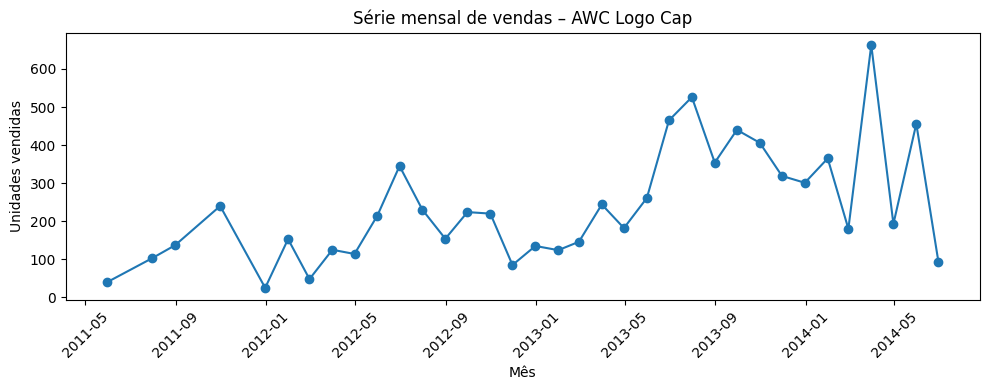

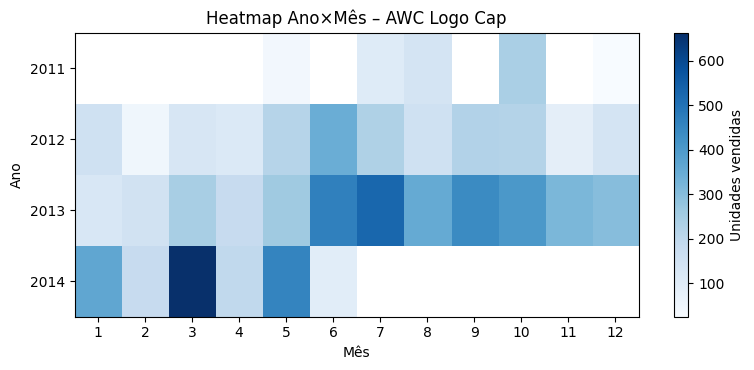

>> Diagnóstico: AWC Logo Cap apresenta maior média de vendas no mês 3 e menor no mês 2.
Isso indica padrão sazonal recorrente, possivelmente ligado a fatores de calendário/estação.
>> M10B OK.


In [ ]:
# ╭────────────────────────────────────────────╮
# │ 10B) Sazonalidade – identificação e análise │
# ╰────────────────────────────────────────────╯
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("\n>> M10B: Iniciando análise de sazonalidade...")

# --- usar df existente ---
df = df.copy()  # substitua 'df' pelo nome do dataframe principal caso esteja diferente

# garantir data mensal
df['month_end_date'] = pd.to_datetime(df['month_end_date'])
df['year_month'] = df['month_end_date'].dt.to_period('M').dt.to_timestamp('M')

# agregação mensal por produto
monthly = (df.groupby(['product_id', 'product_name', 'year_month'], as_index=False)
             ['total_items_sold'].sum())

# escolher 1 produto (top1 em vendas totais)
top_product = (monthly.groupby(['product_id','product_name'])['total_items_sold']
                      .sum().sort_values(ascending=False).head(1).reset_index())

pid, pname = top_product.iloc[0]['product_id'], top_product.iloc[0]['product_name']
serie = monthly[monthly['product_id']==pid].sort_values('year_month')

print(f"Produto selecionado para análise de sazonalidade: {pname} (ID {pid})")

# série temporal mensal
plt.figure(figsize=(10,4))
plt.plot(serie['year_month'], serie['total_items_sold'], marker='o')
plt.title(f"Série mensal de vendas – {pname}")
plt.xlabel("Mês"); plt.ylabel("Unidades vendidas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# heatmap ano x mês
heat = (serie.assign(year=serie['year_month'].dt.year,
                     month=serie['year_month'].dt.month)
              .pivot_table(index='year', columns='month',
                           values='total_items_sold', aggfunc='sum'))

plt.figure(figsize=(8,3.8))
plt.imshow(heat.values, aspect='auto', cmap='Blues')
plt.xticks(np.arange(heat.shape[1]), heat.columns.tolist())
plt.yticks(np.arange(heat.shape[0]), heat.index.tolist())
plt.colorbar(label='Unidades vendidas')
plt.title(f"Heatmap Ano×Mês – {pname}")
plt.xlabel("Mês"); plt.ylabel("Ano")
plt.tight_layout()
plt.show()

# diagnóstico simples de sazonalidade
meses_top = serie.groupby(serie['year_month'].dt.month)['total_items_sold'].mean()
mes_mais_forte = meses_top.idxmax()
mes_mais_fraco = meses_top.idxmin()

print(f">> Diagnóstico: {pname} apresenta maior média de vendas no mês {mes_mais_forte} "
      f"e menor no mês {mes_mais_fraco}.")
print("Isso indica padrão sazonal recorrente, possivelmente ligado a fatores de calendário/estação.")
print(">> M10B OK.")
